In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

In [2]:
x_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

In [3]:
print(x_train[: , 0])
print(x_train[: , 1])

[0.5 1.  1.5 3.  2.  1. ]
[1.5 1.  0.5 0.5 2.  2.5]


In [4]:
# Plotting data

def plot_data(x,y,ax):
  pos = (y==1).flatten()
  neg = (y==0).flatten()

  ax.scatter(x[pos, 0], x[pos, 1], label = 'y=1', marker='x', c='r')
  ax.scatter(x[neg, 0], x[neg, 1], label = 'y=0', marker='o', c='b')
  ax.axis([0,4,0,4])
  # ax.set_title("Dataset Distribution")
  ax.legend()
  # ax.set_xlabel("$x_0$")
  # ax.set_ylabel("$x_1$")

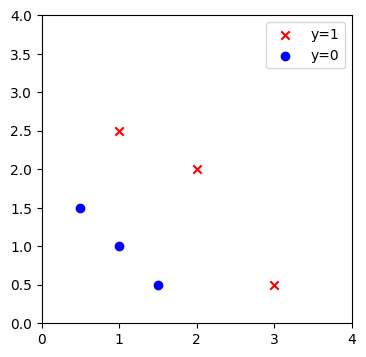

In [5]:
fig, ax = plt.subplots(1,1, figsize=(4,4))
plot_data(x_train, y_train , ax)

plt.show()

In [6]:
# Logistic Gradient Descent

def logistic_gradient_descent(x,y,w,b):

  m,n = x.shape
  dj_dw = np.zeros(n)
  dj_db = 0

  for i in range(m):
    z = np.dot(w, x[i]) + b
    f_wb_i = 1 / (1 + np.exp(-z))

    error_i = f_wb_i - y[i]
    dj_dw_i = error_i * x[i]

    dj_dw += dj_dw_i
    dj_db = dj_db + error_i

  dj_dw = (1/m) * dj_dw
  dj_db = (1/m) * dj_db

  return dj_dw, dj_db

In [7]:
w = np.array([1,1])
b= 2
dj_dw , dj_db = logistic_gradient_descent(x_train, y_train, w, b)
print(dj_dw)
print(dj_db)

[0.48746926 0.48814762]
0.48923807858754975


In [8]:
w = np.array([2, 3])
b= 1
dj_dw , dj_db = logistic_gradient_descent(x_train, y_train, w, b)
print(dj_dw)
print(dj_db)

[0.49833339 0.49883943]
0.49861806546328574


In [9]:
def sigmoid(z):
  g = 1 / (1 + np.exp(-z))
  return g

In [10]:
def logisitc_cost(x, y, w, b):
  m,n = x.shape
  j_wb = 0
  for i in range(m):
    z_i = np.dot(w, x[i]) + b
    f_wb_i = sigmoid(z_i)
    j_wb_i = -y[i] * np.log(f_wb_i) - (1 - y[i]) * np.log(1 - f_wb_i)
    j_wb += j_wb_i

  j_wb = j_wb / m
  return j_wb

In [11]:
from typing import Iterator
def gradient_descent(x,y,w_in,b_in,alpha,iters, logistic_gradient_fun, cost_fun):
  cost_history = []
  w = copy.deepcopy(w_in)
  b = b_in

  for i in range(iters):

    dj_dw, dj_db = logistic_gradient_fun(x,y,w,b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i < 1000:
      cost_history.append(cost_fun(x,y,w,b))

    if i % math.ceil(iters / 10 ) == 0:
      print(f"Iterations: {i:4d}, Cost: {cost_history[-1]}")

  return w , b, cost_history

In [12]:
w = np.zeros_like(x_train[0])
b = 1
alpha = 0.1
iters = 10000

w_f , b_f, cost_hist = gradient_descent(x_train , y_train , w, b, alpha , iters, logistic_gradient_descent, logisitc_cost)
print(f"w final: {w_f} , b final : {b_f}")


Iterations:    0, Cost: 0.8053167896947814
Iterations: 1000, Cost: 0.169191009861858
Iterations: 2000, Cost: 0.169191009861858
Iterations: 3000, Cost: 0.169191009861858
Iterations: 4000, Cost: 0.169191009861858
Iterations: 5000, Cost: 0.169191009861858
Iterations: 6000, Cost: 0.169191009861858
Iterations: 7000, Cost: 0.169191009861858
Iterations: 8000, Cost: 0.169191009861858
Iterations: 9000, Cost: 0.169191009861858
w final: [5.27194991 5.06885616] , b final : -14.196755795245483


Text(0, 0.5, '$x_1$')

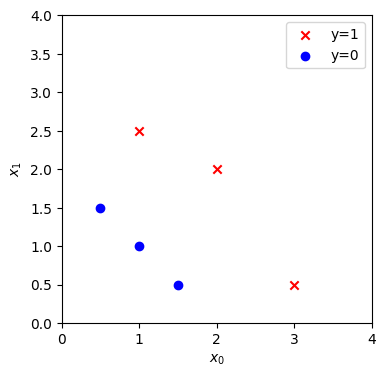

In [13]:
fig, ax = plt.subplots(1,1, figsize = (4,4))

plot_data(x_train, y_train, ax)
ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")


In [14]:
def logistic_regression(x,w,b):

  m = x.shape[0]
  f_wb = np.zeros(m)

  for i in range(m):
    z_i = np.dot(w, x[i]) + b
    f_wb_i = sigmoid(z_i)
    f_wb[i] = f_wb_i

  return f_wb


In [15]:
print(logistic_regression(x_train, w_f, b_f))

[0.01875252 0.0207153  0.02287874 0.98453396 0.99847595 0.97696272]


# calclatind x0 and x1
# for x0 , x1 should be 0

   w0 * x0 + w1 * x1 + b = 0

   w0 * x0 + w1 * 0 + b = 0

   w0 *  x0 + 0 + b = 0

   w0 * x0 = -b

   x0 = -b/w0
   

# T calculate x1, x0 must be 0

   w0 * x0 + w1 * x1 + b = 0

   w0 * 0 + w1 * x1 + b = 0

   0 + w1 * x1 + b = 0

   w1 * x1 = -b

   x1 = -b/w1


   so, this is how we will get the cordinates for decision boundary

In [25]:
def coordinates(x, w, b):
  m,n = x.shape
  # x0 = np.array(n)
  # x1 = np.array(n)
  for i in range(n):
    x0 = -b / w[0]
    x1 = -b / w[1]

    # x0[i] = x0
    # x1[i] = x1
  return x0 , x1

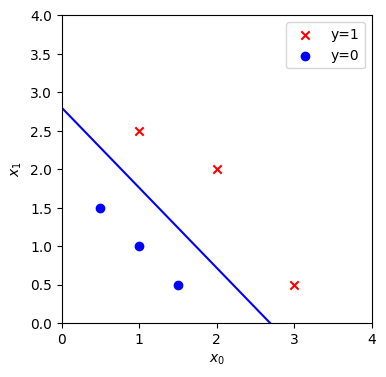

In [28]:
fig, ax = plt.subplots(1,1, figsize = (4,4))

plot_data(x_train, y_train, ax)
ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")

x0 = -b_f / w_f[0]
x1 = -b_f / w_f[1]
ax.plot([x0 , 0], [0, x1], c='b')
plt.show()

In [ ]:
# for single feature dataset

In [31]:
x_train1 = np.array([0., 1, 2, 3, 4, 5])
y_train1 = np.array([0,  0, 0, 1, 1, 1])

In [30]:
def single_feature_plot(x, y, ax):
  ax.scatter(x, y, label = 'Single Feature dataset distribution')


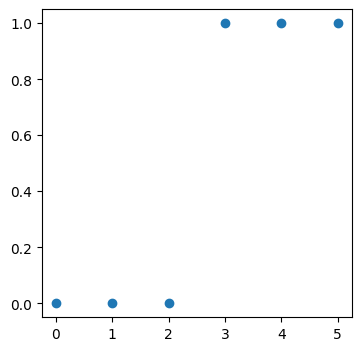

In [32]:
fig, ax = plt.subplots(1,1, figsize=(4,4))
single_feature_plot(x_train1, y_train1, ax)


In [40]:
# we will use boolean mask inside the function to show both labels differnetly.
def single_feature_plot(x, y, ax):
  pos = (y==1)
  neg = (y==0)

  ax.scatter(x[pos], y[pos], label='y=1', c='r', marker='x')
  ax.scatter(x[neg], y[neg], label = 'y=0', c='b', marker='o')
  ax.set_title("Singe Feature")
  ax.set_xlabel("$x_0$")
  ax.set_ylabel("$x_1$")
  ax.legend()

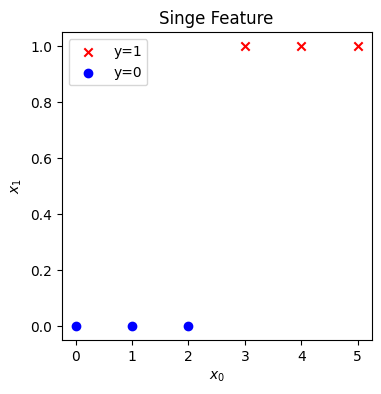

In [41]:
fig, ax = plt.subplots(1,1, figsize=(4,4))
single_feature_plot(x_train1, y_train1, ax)
